# 07 — Grad-CAM (Explainability)

**Day:** 7 of the project plan
**Goal:** look *inside* the best model. Grad-CAM heatmaps highlight the regions
of an input image that drive the prediction, which is the cheapest credible way
to argue "this isn't just memorization, the model attends to plausible MRI
structure."

The plan asks for 4-6 sample images per chosen model:
* 2 correctly classified
* 2 incorrectly classified
* spread across classes when possible

We render **three side-by-side panels per image**: original, raw heatmap, overlay.
Per-row titles state predicted vs true label and softmax confidence.

> The plan suggests running this on the *best* model only. We default to
> MobileNetV2 (typically the best on this dataset) and also produce panels
> for the other two so the final report can compare *where each model looks*.


## 0. Environment setup

In [1]:
import os, sys
from pathlib import Path

os.environ.setdefault("KERAS_BACKEND", "torch")

def _find_project_root():
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "src" / "config.py").exists():
            return cand
    raise RuntimeError("Could not find src/config.py.")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    import google.colab; IN_COLAB = True
    from google.colab import drive; drive.mount("/content/drive", force_remount=False)
except ImportError:
    IN_COLAB = False
print("In Colab:", IN_COLAB, "  Keras backend:", os.environ["KERAS_BACKEND"])


In Colab: False   Keras backend: torch


In [2]:
from src.config import summary, FIGURES_DIR
from src.training import configure_gpu
print(summary())
print("Device info:", configure_gpu())


Environment: local
Project root: C:\Users\miaot\Github\Project_DeepLearningClass
Data root:    C:\Users\miaot\Github\Project_DeepLearningClass\archive\combined_images
Outputs:      C:\Users\miaot\Github\Project_DeepLearningClass\outputs
Classes:      ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']
Image size:   128x128x3
Seed:         42



Device info: {'backend': 'torch', 'gpus': ['NVIDIA GeForce RTX 5080'], 'device': 'GPU', 'keras_version': '3.14.0', 'torch_version': '2.11.0+cu128', 'cuda': '12.8', 'compute_capability': [12, 0]}


## 1. Pick the best model based on Day 6's comparison table

We grab whichever model has the highest macro F1 from the per-model metrics JSONs.
If you've only run smoke-mode training, this picks whichever happened to land
highest on noisy data.


In [3]:
from src.comparison import load_all_metrics
metrics = load_all_metrics()
if not metrics:
    raise RuntimeError(
        "No metrics JSONs found in outputs/predictions/. Run at least one model "
        "training notebook (03/04/05) before running Grad-CAM."
    )
best_model = max(metrics, key=lambda k: metrics[k].get("macro_f1", 0.0))
print("Best by macro F1:", best_model, "->", metrics[best_model]["macro_f1"])
print("All scores:")
for k, m in metrics.items():
    print(f"  {k:14s}  acc={m['accuracy']:.4f}  macroF1={m['macro_f1']:.4f}")


Best by macro F1: baseline_cnn -> 0.9084313987788197
All scores:
  baseline_cnn    acc=0.9053  macroF1=0.9084
  mobilenetv2     acc=0.7426  macroF1=0.7430
  vgg16           acc=0.7290  macroF1=0.7348


## 2. Grad-CAM for the best model

The `run_gradcam_panel` helper:
* loads the saved `.keras` model,
* finds the last `Conv2D` layer programmatically (so this works for the inlined MobileNetV2 and the embedded VGG16 alike),
* picks 2 correct + 2 incorrect test predictions,
* writes a 4-row figure to `outputs/figures/07_gradcam_<model>.png`.

[08:04:25] INFO Loading model: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\models\baseline_cnn.keras


[08:04:25] INFO Last conv layer: conv2d_3


[08:04:25] INFO Correct in test: 5976   Wrong: 625


[08:04:26] INFO Saved Grad-CAM figure: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\07_gradcam_baseline_cnn.png


Saved: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\07_gradcam_baseline_cnn.png


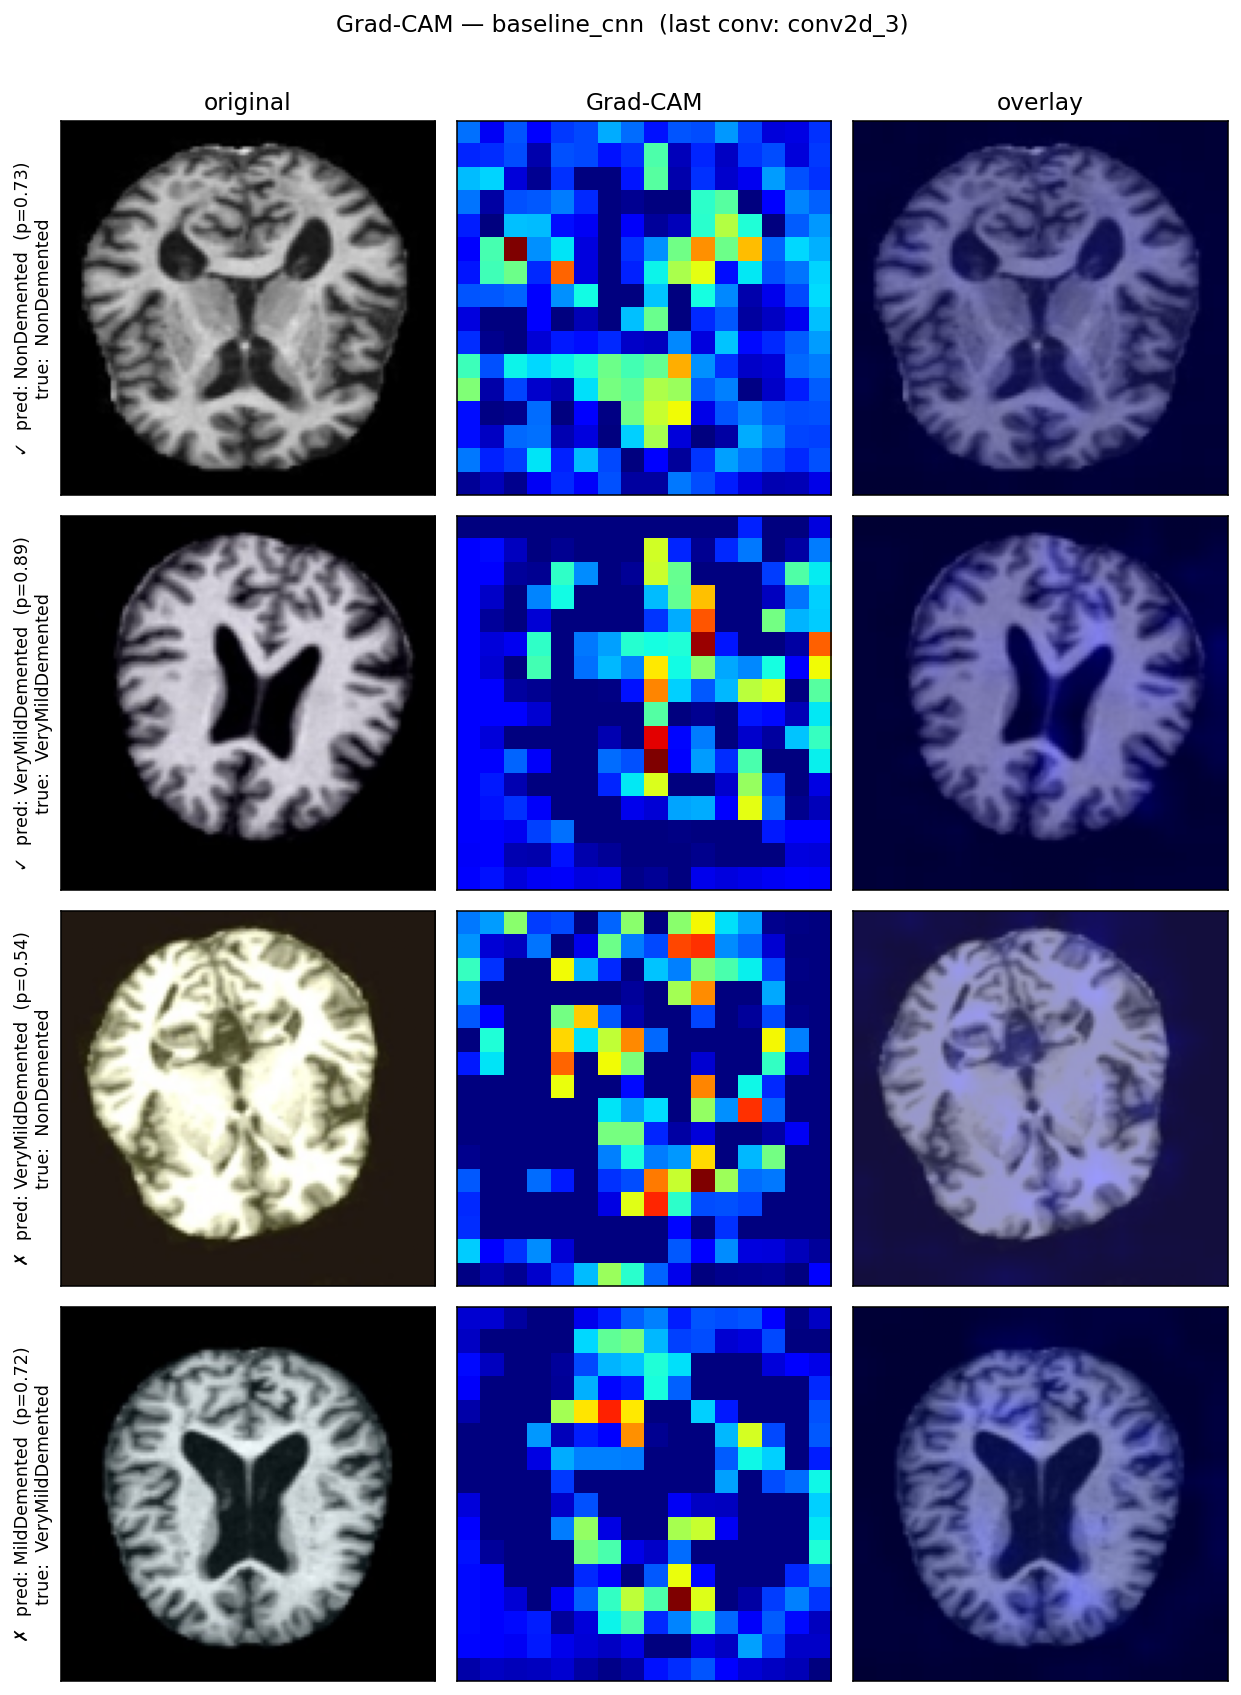

In [4]:
from src.gradcam import run_gradcam_panel
best_path = run_gradcam_panel(model_name=best_model, n_correct=2, n_wrong=2)
print("Saved:", best_path)
from IPython.display import Image as IPyImage
IPyImage(filename=str(best_path))


## 3. Grad-CAM for the other two models (for comparison)

Not strictly required by the plan, but very useful for the final report — you can argue convincingly that *each model looks at different regions*, which is what makes the comparison interesting.

In [5]:
other_models = [m for m in metrics.keys() if m != best_model]
panels = {}
for m in other_models:
    p = run_gradcam_panel(model_name=m, n_correct=2, n_wrong=2)
    print(f"{m}: {p}")
    panels[m] = p


[08:04:26] INFO Loading model: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\models\mobilenetv2.keras


[08:04:26] INFO Last conv layer: Conv_1


[08:04:26] INFO Correct in test: 4902   Wrong: 1699


[08:04:30] INFO Saved Grad-CAM figure: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\07_gradcam_mobilenetv2.png


[08:04:30] INFO Loading model: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\models\vgg16.keras


[08:04:30] INFO Last conv layer: block5_conv3


[08:04:30] INFO Correct in test: 4812   Wrong: 1789


mobilenetv2: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\07_gradcam_mobilenetv2.png


[08:04:30] INFO Saved Grad-CAM figure: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\07_gradcam_vgg16.png


vgg16: C:\Users\miaot\Github\Project_DeepLearningClass\outputs\figures\07_gradcam_vgg16.png


mobilenetv2


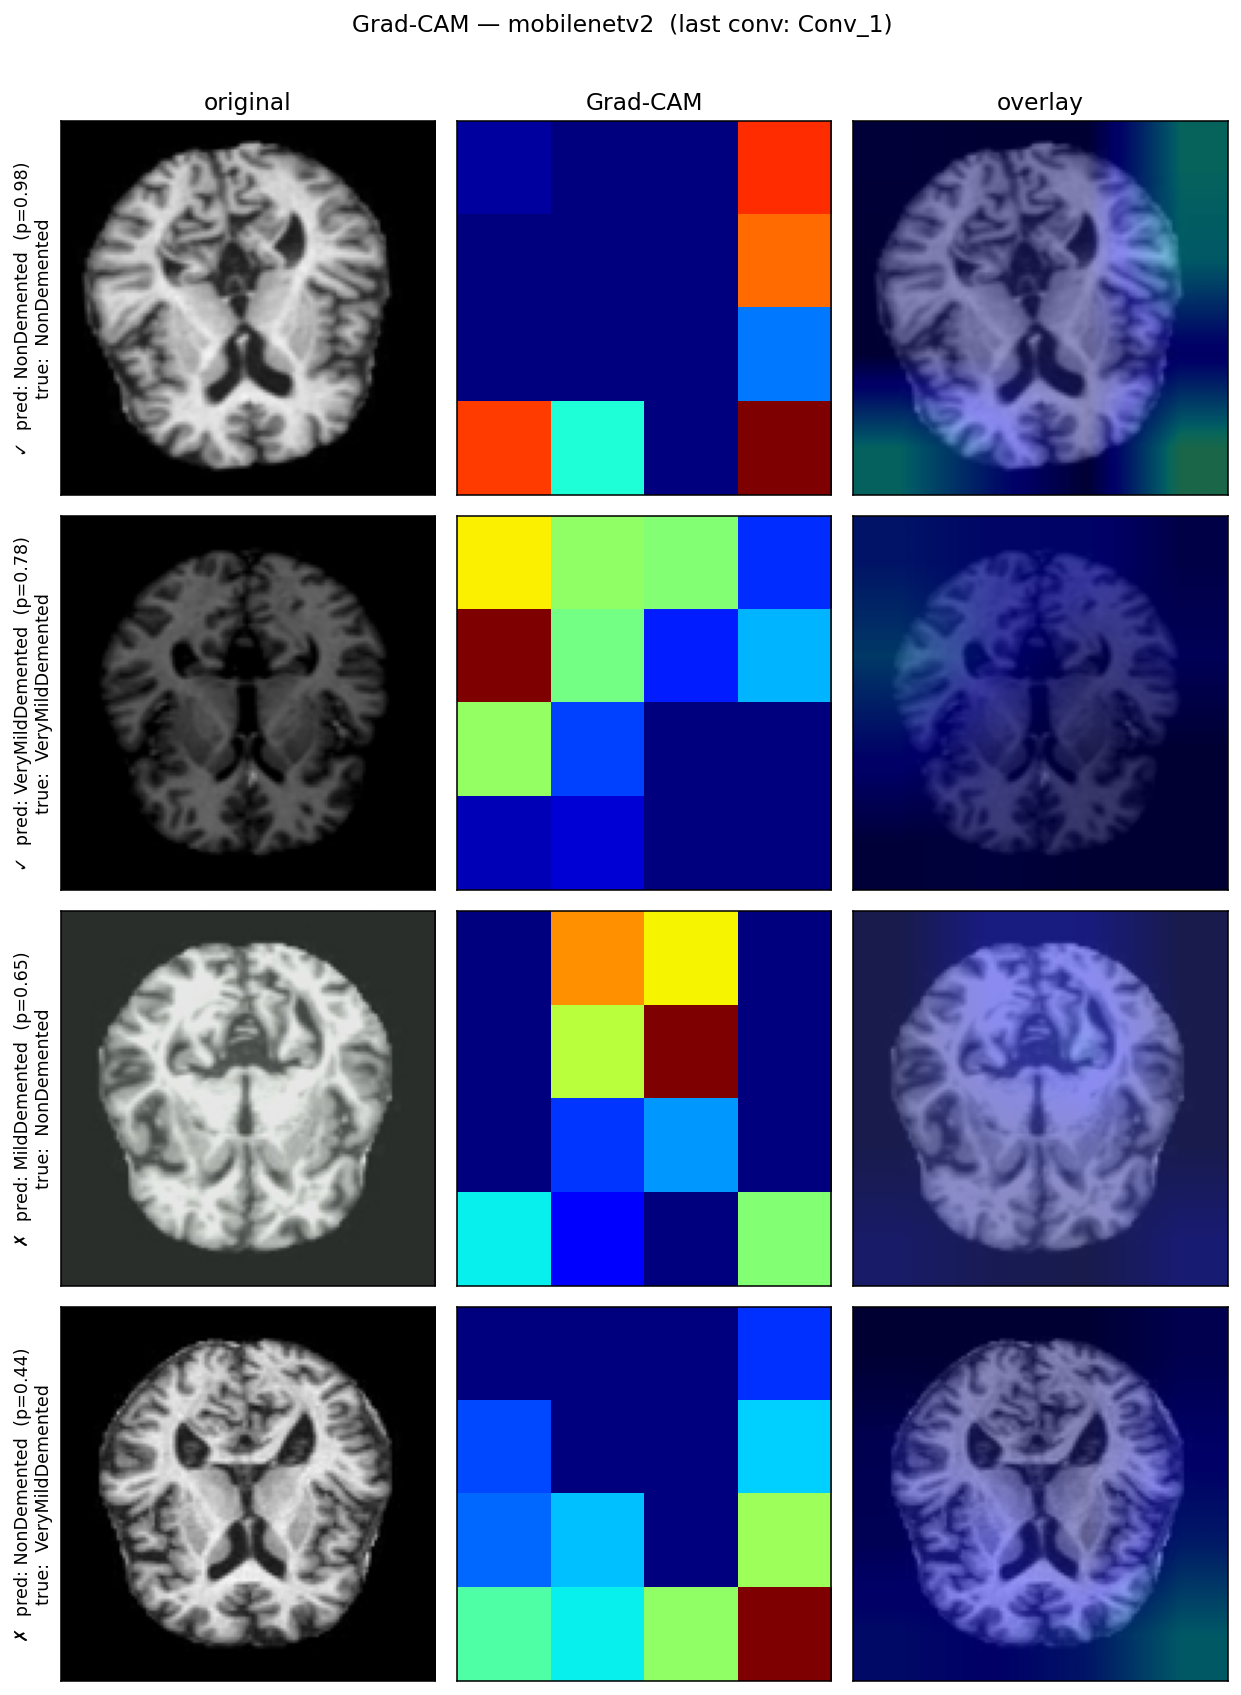

vgg16


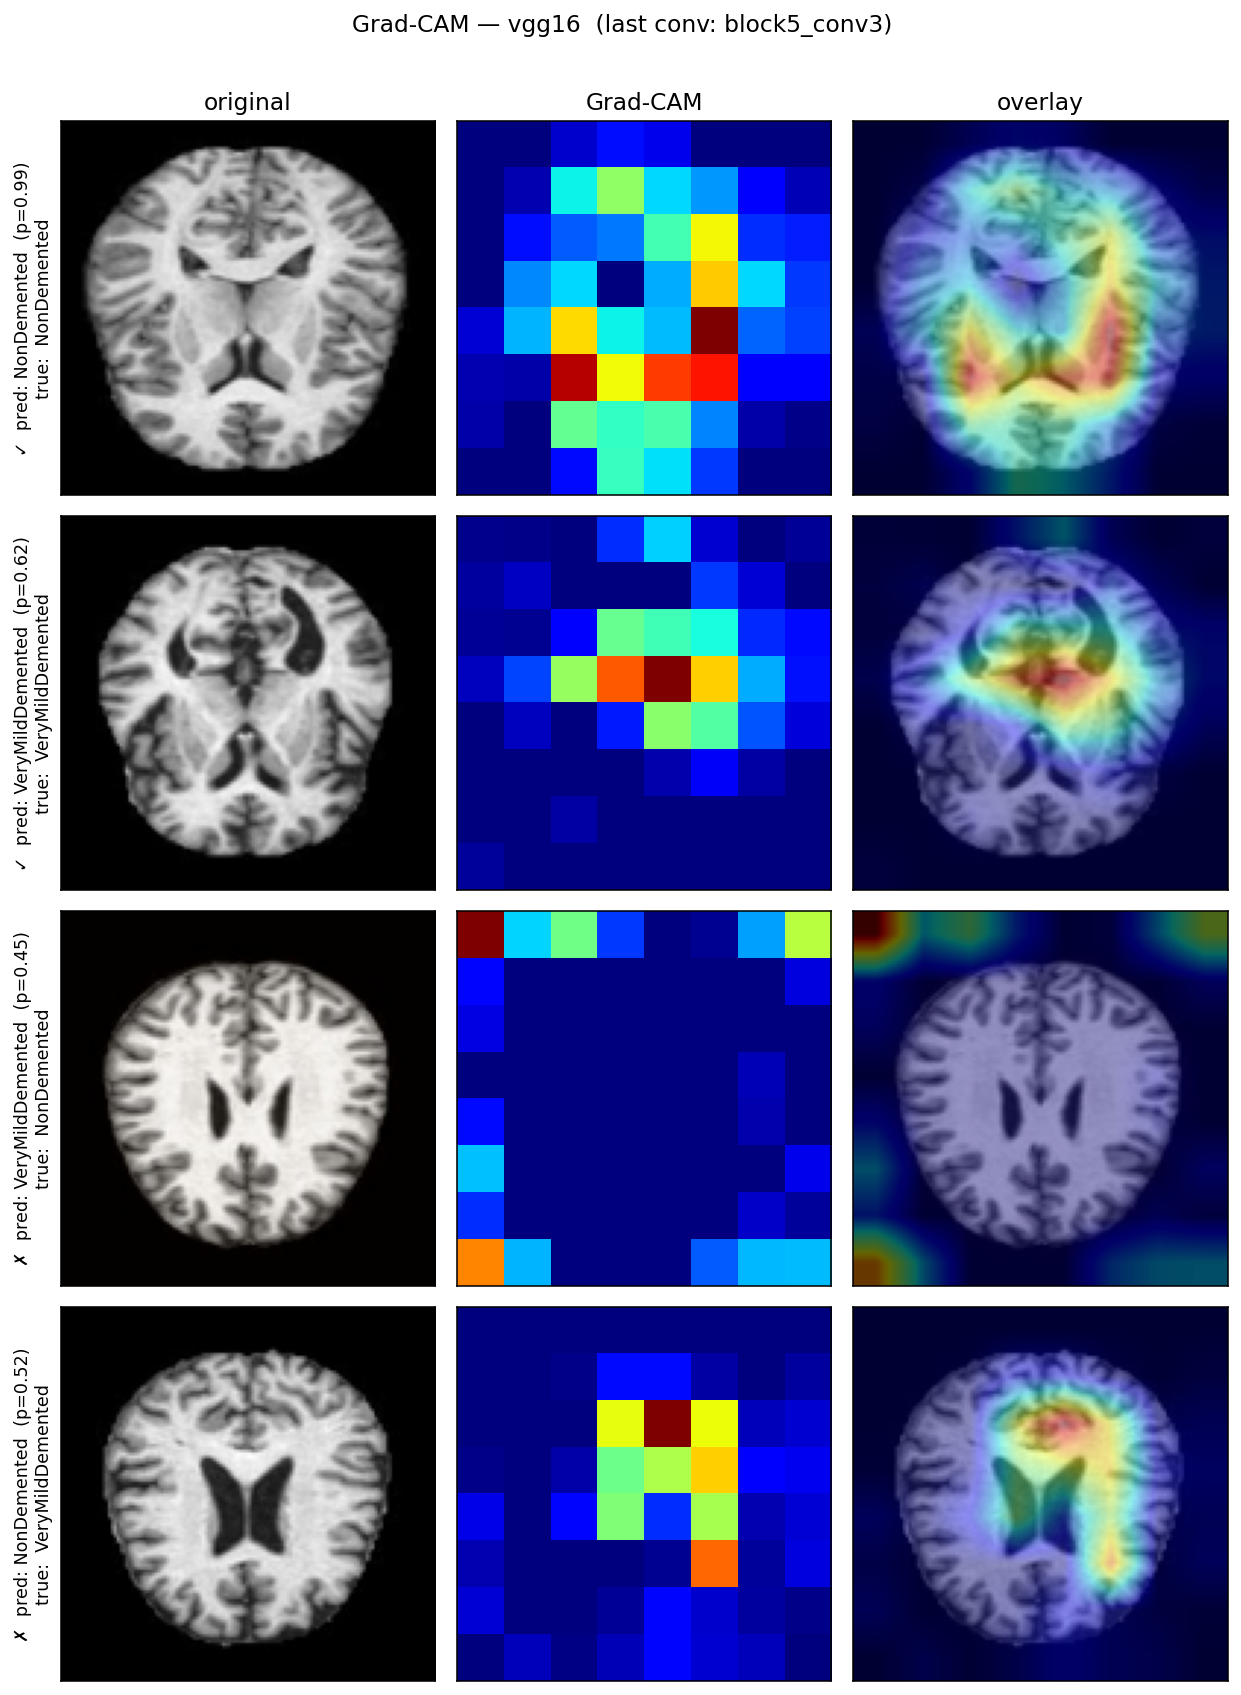

In [6]:
# Show one of the others (loop only renders the last cell explicitly)
for m, p in panels.items():
    print(m)
    display(IPyImage(filename=str(p)))


## 4. How to read these heatmaps

* **Bright red regions** → the cell of the last conv feature map that contributes most to the predicted-class logit.
* **Cool/blue regions** → little contribution to that decision.

What to look for in *MRI* Grad-CAM:
* Attention should fall on the brain parenchyma, not on the corners or skull.
* Heatmap should *change* with the predicted class — if every image lights up the
  same region, the model is probably picking up a non-clinical artifact.
* For wrong predictions, the heatmap often shows the model fixating on something
  irrelevant (border, contrast artifact). That's useful evidence in the report.

## 5. Conclusion for Day 7

Persisted artifacts:
* `outputs/figures/07_gradcam_<model>.png` — one per available trained model.

Next: **the final report** (Day 8-9 in the plan). It pulls the comparison
table, training curves, confusion matrices, the Grad-CAM panels, and bakes the
augmented-and-upsampled limitation into a Discussion section.
